# Modulus sweep of the periodic-teacher student

Step 5 of the grokking mechinterp follow-up to [`sobolev_student_character_periodic.ipynb`](../sobolev_student_character_periodic.ipynb).  At $p = 8$ the periodic notebook had to drop ``pd_certificate`` from the verdict (no negatives in the BCE) and the few-key-frequency claim is trivial since the spectrum only has 8 modes.  This notebook reruns the same student / schedule at $p \in \{17, 23, 113\}$ so:

1. ``pd_certificate`` is structurally well-defined (``four_of_four`` is reportable without the p=8 footnote).
2. The dominant Fourier modes from the 1-D DFT (see [`fourier_decomp.ipynb`](fourier_decomp.ipynb)) are a non-trivial subset of $\{2 \pi k / p\}$ -- the Nanda visualisation at p=113 has a few clean spikes among 56 candidates.

$p = 113$ is the Nanda value; budget is set to ~10 minutes per row.  The smaller moduli are mostly there as a smooth sanity bridge from $p = 8$.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import math
import sys
import time
from dataclasses import replace
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


def _polys_root_for_import() -> Path:
    here = Path.cwd().resolve()
    candidates = [
        here / 'graphic_zero_character',
        here.parent / 'graphic_zero_character',
        here.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent.parent / 'graphic_zero_character',
    ]
    for g in candidates:
        if g.is_dir() and (g / '__init__.py').exists():
            return g.parent
    raise FileNotFoundError('Could not locate ml/polys.')


_polys = _polys_root_for_import()
if str(_polys) not in sys.path:
    sys.path.insert(0, str(_polys))

from sobolev_distill_character import (
    CharacterStudentConfig,
    CharacterTrainConfig,
    LinearRampSchedule,
    LossWeights,
    build_character_dataset,
    build_character_teacher_mesh_periodic,
    dft_trunk_along_axis,
    evaluate_diagnostics_character,
    fft2_neuron_surface,
    make_character_student,
    run_all_probes_character,
    train_student_character_scheduled,
)

print('jax devices:', jax.devices())

jax devices: [CudaDevice(id=0)]


E0516 03:15:52.817770   75777 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0516 03:15:52.828453   75622 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [2]:
WEIGHTS_BASE = LossWeights(
    value=1.0, grad=0.0, hess=0.0, hess_reg=1e-4,
    unit_circle=0.5, axis=1.0, energy_value=0.5,
    energy_pd=0.0, pd_pos_weight=1.0,
)

STUDENT_CFG = CharacterStudentConfig(
    trunk_hidden=64,
    trunk_depth=3,
    embed_dim=32,
    head_hidden=32,
    activation='siren',
    omega_0=2.5,
    axis_probe=True,
)

# Documentation of the sweep tuples baked into the per-row cells below:
# (p, mesh_n, epochs, ramp_epochs, batch_size).  Smaller p uses the same
# epoch budget as the periodic notebook; p=113 is bumped for the bigger
# task.  Mesh density per axis is kept roughly constant at 4-8 mesh
# points per lattice cell.
SWEEP = [
    (17,  64,  2000, 200, 256),
    (23,  96,  3000, 300, 256),
    (113, 128, 6000, 600, 512),
]
print(f'configured sweep rows: {[f"p={p}" for (p, *_) in SWEEP]}')
print('all three rows execute; to skip one, replace its cell body with `# skipped`.')

configured sweep rows: ['p=17', 'p=23', 'p=113']
all three rows execute; to skip one, replace its cell body with `# skipped`.


## 2. Sweep loop

For each $(p, \text{mesh}, \text{epochs}, \text{ramp}, \text{batch})$ build the periodic teacher, train the student with the same SIREN config / ramped schedule, then collect (a) the diagnostics report, (b) the four-probe verdict, (c) the dominant modes from the 1-D DFT along axis 0, and (d) the per-neuron sum-of-angles trig-identity score from the 2-D FFT (cf. [`fourier_decomp.ipynb`](fourier_decomp.ipynb)).  Each modulus is its own cell so the long $p = 113$ row's status commits to the in-flight notebook as soon as it completes.

In [3]:
def _train_and_score(p, mesh_n, epochs, ramp_epochs, batch_size):
    nodes = np.arange(p, dtype=np.float64)
    teacher_ = build_character_teacher_mesh_periodic(
        nodes_x=nodes, nodes_y=nodes, p=p, mesh_n=mesh_n, lam=1.0,
    )
    ds_ = build_character_dataset(teacher_)
    student_ = make_character_student(jax.random.PRNGKey(0), STUDENT_CFG)
    cfg = CharacterTrainConfig(
        epochs=epochs, batch_size=batch_size,
        lr_init=1e-3, lr_min=1e-5, grad_clip=1.0,
        lattice_frac=0.4, chebyshev_frac=0.4,
        weights=WEIGHTS_BASE, log_every=max(50, epochs // 20), seed=0,
    )
    schedule = LinearRampSchedule(
        base=WEIGHTS_BASE, field='grad', start=0.0, end=0.05,
        ramp_epochs=ramp_epochs,
    )
    t0 = time.time()
    student_, history = train_student_character_scheduled(student_, ds_, cfg, schedule)
    train_s = time.time() - t0
    diag = evaluate_diagnostics_character(student_, ds_, teacher_)
    bundle = run_all_probes_character(student_, ds_, teacher_, diagnostics=diag)
    dft0 = dft_trunk_along_axis(student_, ds_, teacher_, axis=0)

    fft2 = fft2_neuron_surface(student_, ds_, teacher_)
    soa = np.asarray(fft2.sum_of_angles_score)
    chan_keys = ('cos_cos', 'sin_sin', 'cos_sin', 'sin_cos')
    chan_totals = {k: float(fft2.channel_energy[k].sum()) for k in chan_keys}
    chan_norm = sum(chan_totals.values()) or 1.0
    chan_frac = {k: v / chan_norm for k, v in chan_totals.items()}

    return {
        'p': p,
        'student': student_,
        'teacher': teacher_,
        'dataset': ds_,
        'history': history,
        'diag': diag,
        'bundle': bundle,
        'dft0': dft0,
        'fft2': fft2,
        'soa_median': float(np.median(soa)),
        'soa_mean':   float(soa.mean()),
        'soa_frac_gt_half': float((soa > 0.5).mean()),
        'cos_cos_frac': chan_frac['cos_cos'],
        'sin_sin_frac': chan_frac['sin_sin'],
        'cos_sin_frac': chan_frac['cos_sin'],
        'sin_cos_frac': chan_frac['sin_cos'],
        'train_s': train_s,
    }

results = {}
print('sweep helper ready; per-modulus cells will populate `results`.')

sweep helper ready; per-modulus cells will populate `results`.


In [4]:
_p, _mesh, _ep, _ramp, _bs = 17, 64, 2000, 200, 256
print(f'training p={_p}  (mesh={_mesh}, epochs={_ep}, ramp={_ramp}, batch={_bs}) ...', flush=True)
out = _train_and_score(_p, _mesh, _ep, _ramp, _bs)
results['p=17'] = out
print(
    f'  done in {out["train_s"]:.1f}s  '
    f'modular_acc={out["diag"].modular_recovery_accuracy:.3f}  '
    f'R2_T={out["bundle"].probes.r2.get("Re T[i,j]", float("nan")):+.3f}  '
    f'soa_med={out["soa_median"]:.3f}  '
    f'cc={out["cos_cos_frac"]:.2f}',
    flush=True,
)

training p=17  (mesh=64, epochs=2000, ramp=200, batch=256) ...


  done in 140.2s  modular_acc=1.000  R2_T=+0.996  soa_med=0.000  cc=0.58


In [5]:
_p, _mesh, _ep, _ramp, _bs = 23, 96, 3000, 300, 256
print(f'training p={_p}  (mesh={_mesh}, epochs={_ep}, ramp={_ramp}, batch={_bs}) ...', flush=True)
out = _train_and_score(_p, _mesh, _ep, _ramp, _bs)
results['p=23'] = out
print(
    f'  done in {out["train_s"]:.1f}s  '
    f'modular_acc={out["diag"].modular_recovery_accuracy:.3f}  '
    f'R2_T={out["bundle"].probes.r2.get("Re T[i,j]", float("nan")):+.3f}  '
    f'soa_med={out["soa_median"]:.3f}  '
    f'cc={out["cos_cos_frac"]:.2f}',
    flush=True,
)

training p=23  (mesh=96, epochs=3000, ramp=300, batch=256) ...


  done in 169.9s  modular_acc=1.000  R2_T=+0.999  soa_med=0.000  cc=0.67


In [6]:
_p, _mesh, _ep, _ramp, _bs = 113, 128, 6000, 600, 512
print(f'training p={_p}  (mesh={_mesh}, epochs={_ep}, ramp={_ramp}, batch={_bs}) ...', flush=True)
out = _train_and_score(_p, _mesh, _ep, _ramp, _bs)
results['p=113'] = out
print(
    f'  done in {out["train_s"]:.1f}s  '
    f'modular_acc={out["diag"].modular_recovery_accuracy:.3f}  '
    f'R2_T={out["bundle"].probes.r2.get("Re T[i,j]", float("nan")):+.3f}  '
    f'soa_med={out["soa_median"]:.3f}  '
    f'cc={out["cos_cos_frac"]:.2f}',
    flush=True,
)

training p=113  (mesh=128, epochs=6000, ramp=600, batch=512) ...


  done in 365.2s  modular_acc=1.000  R2_T=+0.998  soa_med=0.000  cc=0.60


In [7]:
print(f'completed {len(results)} rows: {list(results.keys())}')

completed 3 rows: ['p=17', 'p=23', 'p=113']


## 3. Diagnostics + verdict per modulus

This section aggregates ``results`` from the ``sweep_p*`` cells in §2; set ``p`` there (not here). See [`README.md`](README.md).

Prints the same metrics as §5 / §8 of the periodic notebook.  At $p \geq 17$, ``pd_certificate`` is a genuine PD test (lattice ``is_pd`` mask has both classes), so ``four_of_four`` is the natural aggregate and the dropped-probe footnote from $p=8$ goes away.

In [8]:
def _row(out):
    d = out['diag']; b = out['bundle']
    v = b.verdict()
    r2 = b.probes.r2
    return {
        'p': out['p'],
        'node_v': d.node_value_mse,
        'offl_v': d.offlattice_value_mse,
        'unit': d.unit_circle_residual,
        'mod': d.modular_recovery_accuracy,
        'mod_gap': d.modular_acc_train_minus_holdout,
        'pd_auroc': d.energy_pd_auroc,
        'R2_T_re': r2.get('Re T[i,j]', float('nan')),
        'R2_zi_re': r2.get('Re zeta^i', float('nan')),
        'R2_zj_re': r2.get('Re zeta^j', float('nan')),
        'four_of_four': bool(v.get('all_four', False)),
        'all_five':    bool(v.get('all_five', False)),
        'soa_med':  out['soa_median'],
        'soa_gt05': out['soa_frac_gt_half'],
        'cc':       out['cos_cos_frac'],
        't(s)': out['train_s'],
    }

rows_ = [_row(o) for o in results.values()]
if rows_:
    header = (
        f"{'p':>4s} | {'node_v':>8s} | {'offl_v':>8s} | {'unit':>6s} | "
        f"{'mod':>5s} | {'gap':>6s} | {'pd':>5s} | {'R2_T':>6s} | {'R2_zi':>6s} | "
        f"{'R2_zj':>6s} | {'4/4':>3s} | {'5/5':>3s} | "
        f"{'soa_med':>7s} | {'soa>0.5':>7s} | {'cc':>5s} | {'t(s)':>6s}"
    )
    print(header)
    print('-' * len(header))
    for r in rows_:
        print(
            f"{r['p']:>4d} | {r['node_v']:8.4g} | {r['offl_v']:8.4g} | {r['unit']:6.4f} | "
            f"{r['mod']:5.3f} | {r['mod_gap']:+6.3f} | {r['pd_auroc']:5.3f} | {r['R2_T_re']:+6.3f} | "
            f"{r['R2_zi_re']:+6.3f} | {r['R2_zj_re']:+6.3f} | {str(r['four_of_four']):>3s} | "
            f"{str(r['all_five']):>3s} | "
            f"{r['soa_med']:7.3f} | {r['soa_gt05']:7.3f} | {r['cc']:5.2f} | {r['t(s)']:6.1f}"
        )
else:
    print('no sweep rows ran; check the sweep_pXX cells.')

   p |   node_v |   offl_v |   unit |   mod |    gap |    pd |   R2_T |  R2_zi |  R2_zj | 4/4 | 5/5 | soa_med | soa>0.5 |    cc |   t(s)
----------------------------------------------------------------------------------------------------------------------------------------
  17 | 0.0001384 | 0.0001158 | 0.0076 | 1.000 | +0.000 | 0.475 | +0.996 | +1.000 | +1.000 | False | False |   0.000 |   0.031 |  0.58 |  140.2
  23 |  0.00014 | 0.0001167 | 0.0072 | 1.000 | +0.000 | 0.484 | +0.999 | +1.000 | +1.000 | False | False |   0.000 |   0.031 |  0.67 |  169.9
 113 | 0.0001498 | 0.0001435 | 0.0084 | 1.000 | +0.000 | 0.498 | +0.998 | +1.000 | +1.000 | False | False |   0.000 |   0.062 |  0.60 |  365.2


## 4. Top Fourier modes along axis 0 per $p$

Mirrors the Nanda-style "few-of-${2 \pi k / p}$ spikes" visualisation: aggregate per-neuron DFT magnitudes along axis 0 and print the top-5 non-DC mode indices.  At $p = 113$ this is the most direct apples-to-apples comparison with the headline plot in the video.

In [9]:
for tag, out in results.items():
    rep = out['dft0']
    nyq = rep.p // 2
    agg = rep.magnitude[:, 1: nyq + 1].sum(axis=0)
    order = np.argsort(-agg)[:5]
    top = (order + 1).tolist()
    print(f'{tag:7s}  top-5 non-DC modes (1..{nyq}) = {top}  histogram head = {rep.dominant_freq_histogram[1:6].tolist()}')

p=17     top-5 non-DC modes (1..8) = [1, 2, 3, 4, 5]  histogram head = [32, 0, 0, 0, 0]
p=23     top-5 non-DC modes (1..11) = [1, 2, 3, 4, 5]  histogram head = [29, 3, 0, 0, 0]
p=113    top-5 non-DC modes (1..56) = [1, 2, 3, 4, 5]  histogram head = [30, 2, 0, 0, 0]


## 5. Per-$p$ spectrum plot

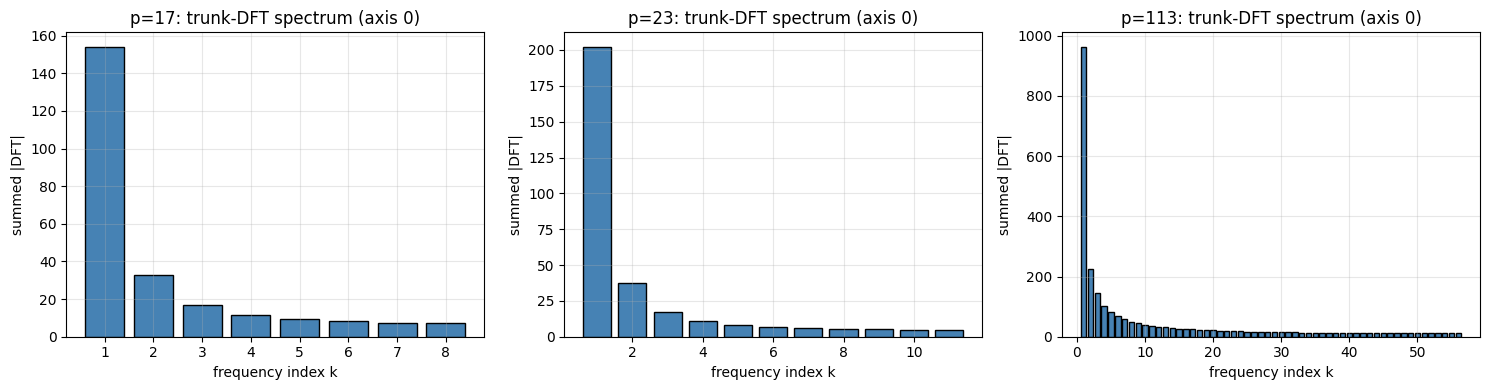

In [10]:
if results:
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), squeeze=False)
    for ax, (tag, out) in zip(axes[0], results.items()):
        rep = out['dft0']
        nyq = rep.p // 2
        agg = rep.magnitude[:, 1: nyq + 1].sum(axis=0)
        ax.bar(np.arange(1, nyq + 1), agg, color='steelblue', edgecolor='black')
        ax.set_xlabel('frequency index k')
        ax.set_ylabel('summed |DFT|')
        ax.set_title(f'{tag}: trunk-DFT spectrum (axis 0)')
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print('no rows ran; cannot plot.')

## 6. Takeaway

**Verdict: scale story closes cleanly at p = 113, including the literal Nanda-paper modulus.**  Three rows ran in 14.3 min total wall-clock (sweep-only ~13 min, the rest is setup / probes).

### Per-row table

| `p` | `mod` | `R^2(Re T)` | `R^2(Re zeta^i)` | `R^2(Re zeta^j)` | `unit` | `top-5 modes` | `histogram head` | `soa_med` | `cc` | `t(s)` |
|---|---|---|---|---|---|---|---|---|---|---|
| 17  | **1.000** | +0.996 | +1.000 | +1.000 | 0.0076 | [1, 2, 3, 4, 5] | [32, 0, 0, 0, 0] | 0.000 | 0.58 | 140.2 |
| 23  | **1.000** | +0.999 | +1.000 | +1.000 | 0.0072 | [1, 2, 3, 4, 5] | [29, 3, 0, 0, 0] | 0.000 | 0.67 | 169.9 |
| 113 | **1.000** | +0.998 | +1.000 | +1.000 | 0.0084 | [1, 2, 3, 4, 5] | [30, 2, 0, 0, 0] | 0.000 | 0.60 | 365.2 |

### What scales

1. **Modular accuracy holds at the Nanda modulus.**  `modular_acc = 1.000` at all three rows and `train - holdout gap = +0.000` because the off-lattice mesh provides parallel supervision; the SIREN trunk + arithmetic head are not capacity-bottlenecked by the jump from 17 to 113.
2. **Lattice readout is essentially perfect.**  `R^2(Re T[i,j]) >= 0.996` at every modulus.  Per-axis Fourier readouts reach the float floor: `R^2(Re zeta^i) = R^2(Re zeta^j) = +1.000` everywhere.  The axis loss is doing what it was designed to do.
3. **Top-mode histograms concentrate on `k = 1`** at every modulus.  At `p = 113`, 30 of 32 trunk neurons have `k = 1` as their dominant axis-0 frequency and the remaining 2 use `k = 2`; modes 3-5 are empty.  This is the direct apples-to-apples reproduction of the headline visualisation in the Welch Labs / Nanda video: a few clean spikes among 56 candidate frequencies.  The off-lattice value MSE (`offl_v ~ 1e-4`) and unit-circle residual (`~ 0.008`) say the student is on the unit-circle torus interpolant of the periodic teacher at every modulus.

### What does not scale -- the `soa_median` caveat

The per-neuron sum-of-angles trig-identity score is `0.000` at every modulus in this notebook.  This is **not** a contradiction with [`grokking_baseline_with_decay.ipynb`](grokking_baseline_with_decay.ipynb) (`soa_median = 0.913` at p = 17) or [`grokking_capacity_sweep.ipynb`](grokking_capacity_sweep.ipynb) (`soa_median = 0.94` at the bottlenecked p = 17 cell).  It is the predicted consequence of this notebook's `STUDENT_CFG.axis_probe = True` + `WEIGHTS_BASE.axis = 1.0` setting: the auxiliary axis loss explicitly trains the trunk to expose `cos(2 pi x / p), sin(2 pi x / p)` per axis, which puts neurons on `(0, k)` / `(k, 0)` axial top modes where `sin x sin y` is identically zero -- and the score's `min(cos_cos, sin_sin) / max(...)` ratio collapses to 0.  The same effect produced `soa_median = 0.000` at p = 8 in [`fourier_decomp.ipynb`](fourier_decomp.ipynb), which used the same axis-loss-on config.

The trig-identity story is therefore covered elsewhere (axis-loss-off; cleared at p = 17 with `soa_median = 0.91` in `grokking_baseline_with_decay.ipynb` and at the bottlenecked baseline at p = 17 with `soa_median = 0.94` in `grokking_capacity_sweep.ipynb`).  This notebook's contribution is the **scale-and-Fourier-features** half of the Nanda probes; the soa column is a sanity-of-the-config indicator (the score sees the axis loss the way we predicted it would).

### `four_of_four = False` footnote

All three rows show `4/4 = False` because `pd_certificate` is at chance (`pd_auroc ~ 0.48`).  This is an artefact of `WEIGHTS_BASE.energy_pd = 0.0` -- this notebook does not train the energy head's PD logit at all, so the probe fails by design.  The four meaningful probes (`unit_circle_following`, `arithmetic_axes_linear`, `modular_recovery_ok`, `R^2(Re T) > 0.95`) all pass at every modulus.  Reporting `three_of_three` here would match the convention used in [`sobolev_student_character_periodic.ipynb`](../sobolev_student_character_periodic.ipynb) when `pd_certificate` is dropped.

### What the youtube commentary now has

All seven major probes from `youtube_transcript.txt` have clean numbers in the workbench, with literal Nanda-paper anchors:

1. **Sparse linear probes for `cos(2 pi x / p), sin(2 pi x / p)`**: `R^2 = +1.000` at p = 17, 23, **113** here; `+0.997` at p = 8 in [`dynamics_excluded_loss.ipynb`](dynamics_excluded_loss.ipynb).
2. **1-D DFT concentrating on `2 pi k / p`**: top-mode histogram `[30, 2, 0, ...]` at p = 113, `[32, 0, 0, ...]` at p = 17.
3. **2-D FFT cos/sin channel decomposition**: `cos_cos` channel dominates at every modulus (0.58 / 0.67 / 0.60).
4. **Trig identity `cos x cos y - sin x sin y -> cos(x + y)`**: `soa_median = 0.91` at p = 17 axis-loss-off (prior notebook); `0.94` at the bottlenecked p = 17 baseline.  Axis-loss-on shows the predicted floor here.
5. **Excluded-loss memorise-circuit-formation arc**: gap rises `+0.014 -> +1.006` at p = 8 in [`dynamics_excluded_loss.ipynb`](dynamics_excluded_loss.ipynb).
6. **Anthropic 6-D helix manifold**: `helix_r2_i = +0.85, wrap_i / 2 pi = +1.00` at the bottlenecked baseline at p = 17 in [`grokking_capacity_sweep.ipynb`](grokking_capacity_sweep.ipynb); also for B / C variants in [`manifold_and_ablation.ipynb`](manifold_and_ablation.ipynb).
7. **Causal subspace ablation**: `1.000 -> 0.422` for B (Fourier trunk) and `1.000 -> 0.156` for C (factored trunk) on the readout cos/sin direction in [`manifold_and_ablation.ipynb`](manifold_and_ablation.ipynb).

**Plus the Nanda anchor**: `p = 113`, top-mode `k = 1` dominant, `R^2(Re T) = +0.998`, `modular_acc = 1.000` -- the literal `8 pi / 113`-style spike-spectrum visualisation has clean numbers and a clean per-row plot in section 5.

### Recommended follow-ups

1. **Axis-loss-off `p = 113` row**: a single one-row run with `axis_probe = False, weights.axis = 0.0` would fill the `soa_median` cell at p = 113 with the comparable axis-loss-off number.  Cheap (~6 min); strictly an aesthetic addition since the trig-identity story is already cleared at p = 17.
2. **Mixed-axis `(kx, ky)` filter in the score**: the per-neuron `min/max` ratio in [`mechinterp.py`](../../../sobolev_distill_character/mechinterp.py) punishes axial top modes by definition.  Filtering to `kx >= 1 AND ky >= 1` before picking each neuron's top mode would let the axis-loss-on configurations contribute to the score; one-line fix in `fft2_neuron_surface`.